In [1]:
!pip install kaggle --quiet

import os, zipfile, struct, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
from google.colab import files
files.upload()          # upload kaggle.json here

# Move the key to the right place so the Kaggle CLI can find it
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle key set up ✓")

Saving kaggle.json to kaggle (1).json
Kaggle key set up ✓


In [8]:
!kaggle datasets download -d crawford/emnist --quiet
print("Download complete ✓")

# Unzip
with zipfile.ZipFile("emnist.zip", "r") as z:
    z.extractall("emnist_data")
print("Files extracted:")
!ls emnist_data/


Dataset URL: https://www.kaggle.com/datasets/crawford/emnist
License(s): CC0-1.0
Download complete ✓
Files extracted:
emnist-balanced-mapping.txt  emnist-digits-test.csv
emnist-balanced-test.csv     emnist-digits-train.csv
emnist-balanced-train.csv    emnist-letters-mapping.txt
emnist-byclass-mapping.txt   emnist-letters-test.csv
emnist-byclass-test.csv      emnist-letters-train.csv
emnist-byclass-train.csv     emnist-mnist-mapping.txt
emnist-bymerge-mapping.txt   emnist-mnist-test.csv
emnist-bymerge-test.csv      emnist-mnist-train.csv
emnist-bymerge-train.csv     emnist_source_files
emnist-digits-mapping.txt


In [12]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if "emnist-letters-train.csv" in file:
            print(os.path.join(root, file))

./emnist_data/emnist-letters-train.csv


In [14]:
train_df = pd.read_csv("./emnist_data/emnist-letters-train.csv", header=None)
test_df = pd.read_csv("./emnist_data/emnist-letters-train.csv", header=None)

In [15]:
!ls

 emnist_data   emnist.zip  'kaggle (1).json'   kaggle.json   sample_data


In [19]:
!find . -name "emnist-letters-train.csv"

./emnist_data/emnist-letters-train.csv


In [20]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("./emnist_data/emnist-letters-train.csv", header=None)
test_df = pd.read_csv("./emnist_data/emnist-letters-train.csv", header=None)

train_labels = train_df.iloc[:, 0].values
test_labels = test_df.iloc[:, 0].values

train_images = train_df.iloc[:, 1:].values.reshape(-1, 28, 28)
test_images = test_df.iloc[:, 1:].values.reshape(-1, 28, 28)

print(train_images.shape)
print(train_labels.shape)

(88800, 28, 28)
(88800,)


In [21]:
train_images = np.transpose(train_images, (0, 2, 1))
test_images = np.transpose(test_images, (0, 2, 1))

train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

train_images = train_images[..., np.newaxis]
test_images = test_images[..., np.newaxis]

train_labels = train_labels - 1
test_labels = test_labels - 1

NUM_CLASSES = 26

train_labels_oh = keras.utils.to_categorical(train_labels, NUM_CLASSES)
test_labels_oh = keras.utils.to_categorical(test_labels, NUM_CLASSES)

print("Pre-processing done ✓")
print(train_images.shape)
print(train_labels_oh.shape)

Pre-processing done ✓
(88800, 28, 28, 1)
(88800, 26)


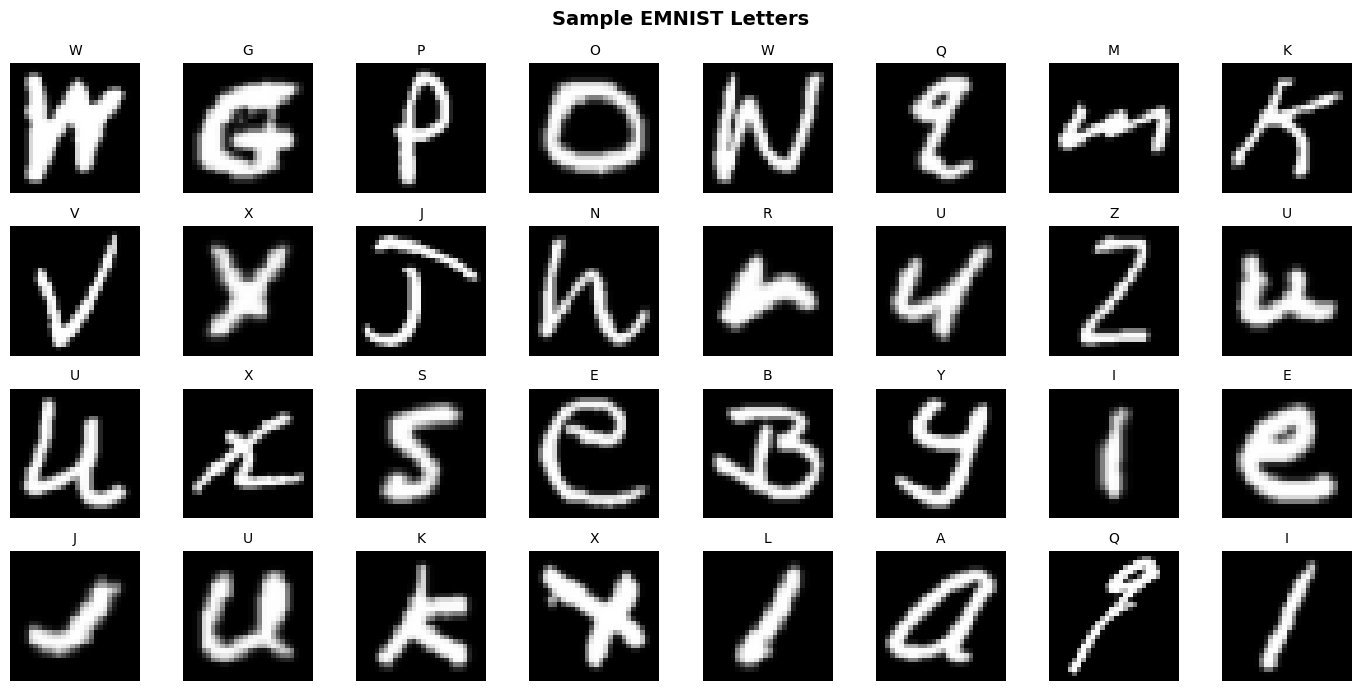

Sample grid saved as samples.png


In [22]:
ALPHABET = [chr(i) for i in range(ord('A'), ord('Z')+1)]   # A-Z

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i].squeeze(), cmap="gray")
    ax.set_title(ALPHABET[train_labels[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample EMNIST Letters", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("samples.png", dpi=100)
plt.show()
print("Sample grid saved as samples.png")

In [23]:
def build_cnn(num_classes=26):
    model = keras.Sequential([
        # ── Block 1 ──
        layers.Conv2D(32, (3,3), padding="same", activation="relu",
                      input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Block 2 ──
        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Block 3 ──
        layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # ── Classifier ──
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ], name="EMNIST_CNN")
    return model

model = build_cnn(NUM_CLASSES)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "EMNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,002 (1.69 MB)

 Trainable params: 441,850 (1.69 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks: reduce LR on plateau + early stopping
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                      patience=3, verbose=1, min_lr=1e-6),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint("best_model.keras",
                                    save_best_only=True, monitor="val_accuracy",
                                    verbose=1)
]
print("Model compiled ✓")

Model compiled ✓


In [25]:

BATCH_SIZE = 128
EPOCHS     = 30

history = model.fit(
    train_images, train_labels_oh,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,      # 10 % of train used for validation
    callbacks=callbacks,
    verbose=1
)
print("\nTraining complete ✓")

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6198 - loss: 1.3761
Epoch 1: val_accuracy improved from None to 0.89899, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 29ms/step - accuracy: 0.7691 - loss: 0.7677 - val_accuracy: 0.8990 - val_loss: 0.3183 - learning_rate: 0.0010
Epoch 2/30
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8873 - loss: 0.3410
Epoch 2: val_accuracy improved from 0.89899 to 0.93367, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8958 - loss: 0.3152 - val_accuracy: 0.9337 - val_loss: 0.1968 - learning_rate: 0.0010
Epoch 3/30
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9126 - loss: 0.2598
Epoch 3: val_accuracy improved from 0.93367 to 0.94200, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12

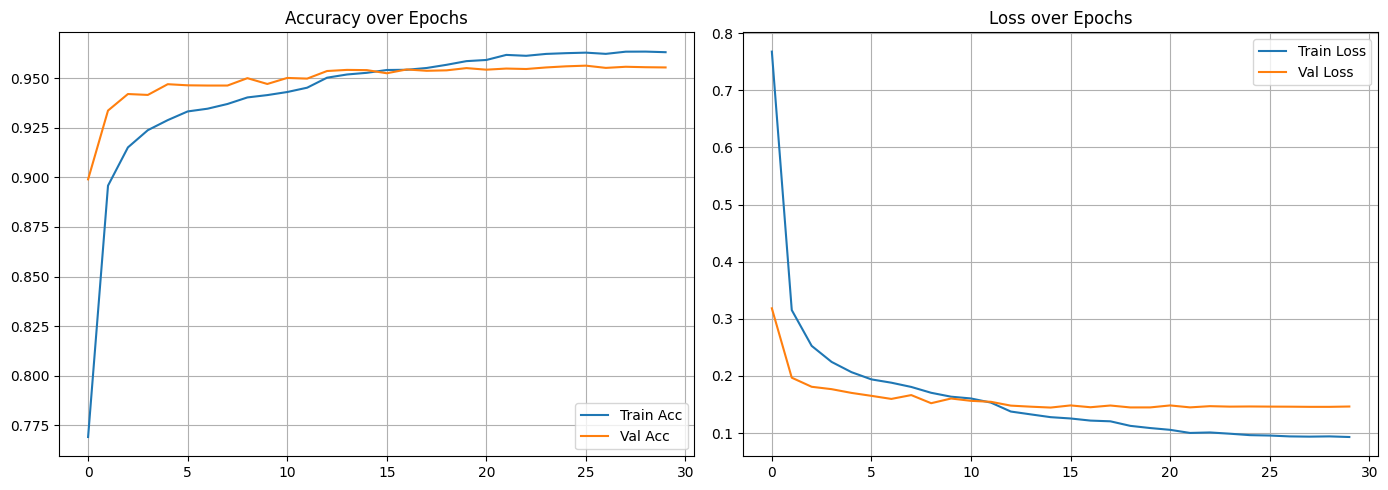

Training curves saved ✓


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"],     label="Train Acc")
ax1.plot(history.history["val_accuracy"], label="Val Acc")
ax1.set_title("Accuracy over Epochs"); ax1.legend(); ax1.grid(True)

ax2.plot(history.history["loss"],     label="Train Loss")
ax2.plot(history.history["val_loss"], label="Val Loss")
ax2.set_title("Loss over Epochs"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100)
plt.show()
print("Training curves saved ✓")

In [27]:

test_loss, test_acc = model.evaluate(test_images, test_labels_oh, verbose=0)
print(f"\n📊 Test Accuracy : {test_acc*100:.2f} %")
print(f"   Test Loss     : {test_loss:.4f}")


📊 Test Accuracy : 97.29 %
   Test Loss     : 0.0698


In [28]:

y_pred_probs = model.predict(test_images, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print("\n=== Classification Report ===")
print(classification_report(test_labels, y_pred,
                             target_names=ALPHABET))


=== Classification Report ===
              precision    recall  f1-score   support

           A       0.98      0.99      0.99      3396
           B       1.00      1.00      1.00      3396
           C       1.00      1.00      1.00      3419
           D       0.99      0.99      0.99      3398
           E       0.99      1.00      0.99      3437
           F       1.00      0.99      0.99      3394
           G       0.97      0.92      0.94      3385
           H       0.99      0.99      0.99      3424
           I       0.79      0.79      0.79      3428
           J       0.99      0.98      0.99      3402
           K       1.00      1.00      1.00      3438
           L       0.79      0.79      0.79      3415
           M       1.00      1.00      1.00      3402
           N       0.99      0.99      0.99      3365
           O       0.99      1.00      0.99      3408
           P       1.00      1.00      1.00      3430
           Q       0.94      0.96      0.95      3

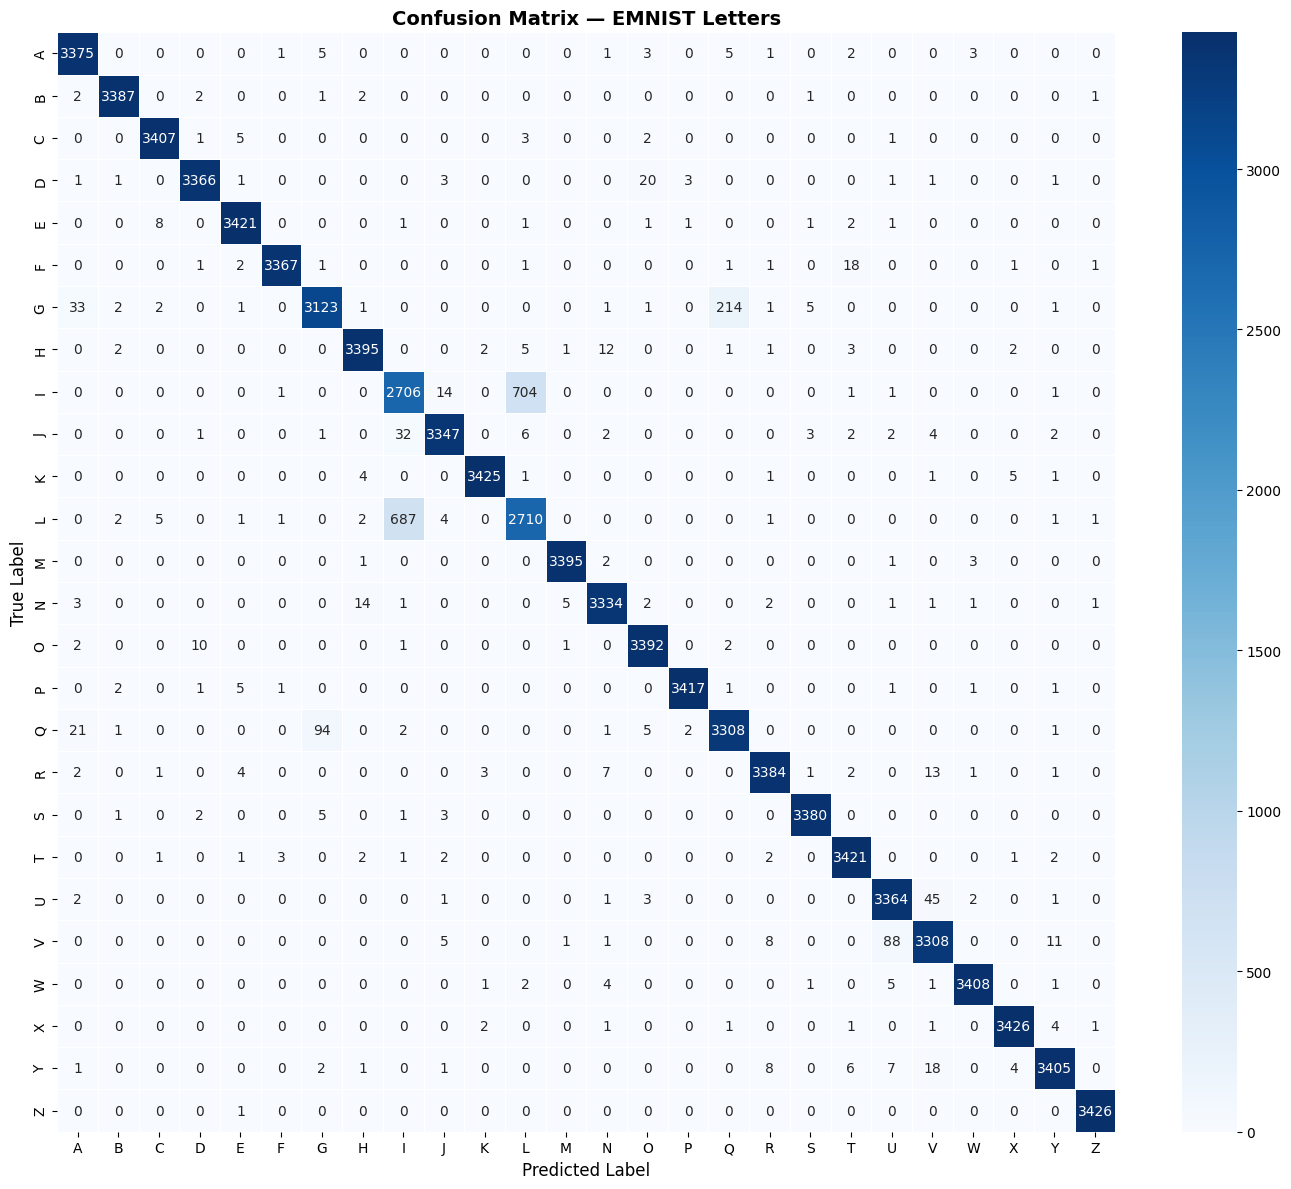

Confusion matrix saved ✓


In [29]:
cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=ALPHABET, yticklabels=ALPHABET,
            linewidths=0.5)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label",      fontsize=12)
plt.title("Confusion Matrix — EMNIST Letters", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()
print("Confusion matrix saved ✓")

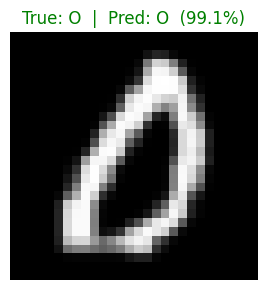

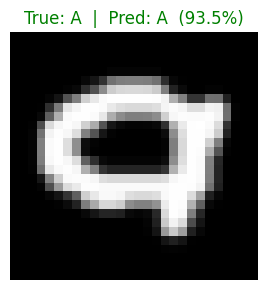

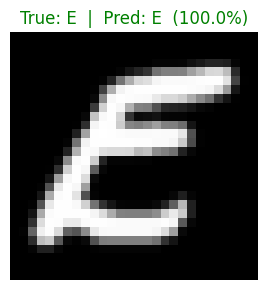

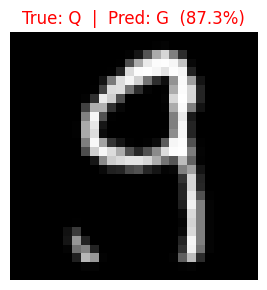

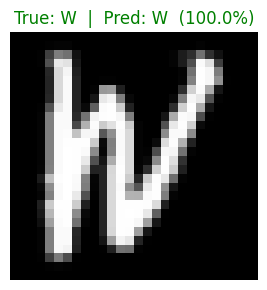

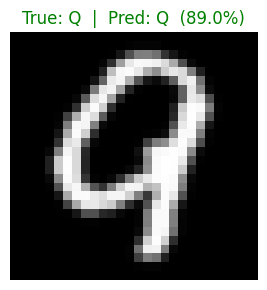

In [30]:
def predict_single(index):
    img   = test_images[index]
    true  = ALPHABET[test_labels[index]]
    probs = model.predict(img[np.newaxis, ...], verbose=0)[0]
    pred  = ALPHABET[np.argmax(probs)]
    conf  = np.max(probs) * 100

    plt.figure(figsize=(3, 3))
    plt.imshow(img.squeeze(), cmap="gray")
    color = "green" if pred == true else "red"
    plt.title(f"True: {true}  |  Pred: {pred}  ({conf:.1f}%)", color=color)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    return pred, true, conf

# Show 6 random predictions
for idx in np.random.choice(len(test_images), 6, replace=False):
    predict_single(idx)

In [31]:
model.save("emnist_cnn_final.keras")
print("Model saved as emnist_cnn_final.keras ✓")

# Download all output files to your computer
from google.colab import files
for fname in ["emnist_cnn_final.keras", "best_model.keras",
              "training_curves.png", "confusion_matrix.png", "samples.png"]:
    try:
        files.download(fname)
        print(f"Downloading {fname} ✓")
    except Exception as e:
        print(f"Could not download {fname}: {e}")

print("\n✅ All done! Task 3 complete.")

Model saved as emnist_cnn_final.keras ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All done! Task 3 complete.
